# Phase 6 — Cost-Aware Decision Rule

Model probabilities alone aren't a decision. This phase turns per-user P(churn) into per-user targeting: which lever to pull, or no intervention at all, subject to a budget cap.

**Sections**
- A. Setup — score every subscriber
- B. Assumptions — intervention menu, LTV, budget
- C. EV per lever per user
- D. Best lever + premium cap
- E. Budget cap + summary
- F. Baseline: blanket $5 at m11
- G. ROI sweep
- H. Sensitivity: uplift assumptions
- I. Verdict

> **Why the decision rule is separate from the model.**
> The model produces P(churn). The policy decides what to do with it. Keeping them separate means we can retune the rule (change costs, LTV, uplift) without retraining.

In [1]:
import sys, pickle
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_subscribers
from src.features.transforms import build_features
from src.models.train import prepare_features
from src.decisions.policy import (
    INTERVENTION_MENU, LTV_BY_TIER, PREMIUM_UPGRADE_CAP_PCT,
    score_all_levers, pick_best_lever, apply_budget_cap,
    apply_premium_cap, summarize_policy, simulate_blanket_campaign,
)

FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## A. Setup

Load the calibrated model, score every subscriber, attach LTV by plan tier.

In [2]:
raw = load_subscribers('../data/subscribers.csv')
df = build_features(raw)
X, y = prepare_features(df)

with open('../models/churn_model_v1.pkl', 'rb') as f:
    artifact = pickle.load(f)
model = artifact['production_model']
X = X[artifact['feature_names']]

p_churn = model.predict_proba(X)[:, 1]
ltv = df['plan_tier'].map(LTV_BY_TIER).values
tenure = df['tenure_months'].values

print(f'Scored {len(p_churn):,} subscribers')
print(f'P(churn): mean={p_churn.mean():.4f}, p90={np.percentile(p_churn, 90):.4f}, max={p_churn.max():.4f}')
print(f'LTV:      mean=${ltv.mean():.0f}, min=${ltv.min():.0f}, max=${ltv.max():.0f}')

Scored 50,000 subscribers
P(churn): mean=0.0532, p90=0.0748, max=0.9693
LTV:      mean=$130, min=$72, max=$228


## B. Assumptions

Curated with the PM. Uplift = fraction of would-have-churners this lever retains. LTV = expected revenue if we save them.

In [3]:
menu_df = pd.DataFrame(INTERVENTION_MENU).T
menu_df['cost'] = menu_df['cost'].map('${:.2f}'.format)
menu_df['uplift'] = menu_df['uplift'].map('{:.0%}'.format)
print('Intervention menu:')
print(menu_df)
print(f'\nLTV by tier:')
for tier, v in LTV_BY_TIER.items():
    print(f'  {tier:<10}  ${v:.0f}')
print(f'\nPremium upgrade cap: {PREMIUM_UPGRADE_CAP_PCT:.0%} of subscriber base')

Intervention menu:
                    cost uplift
curated_playlist   $1.00     5%
credit_5           $5.00    15%
premium_upgrade   $12.00    25%

LTV by tier:
  Basic       $72
  Standard    $140
  Premium     $228

Premium upgrade cap: 5% of subscriber base


> **Uplift is a PM assumption, not a measurement.**
> These numbers came from a 2024 pilot; a proper measurement would need an A/B test per lever. Section H sweeps uplift ±50% to check whether the recommendation is robust to the assumption.

## C. EV per lever per user

For each user × lever combo:

```
EV(user, L) = P(churn | user) × uplift(L) × LTV(tier) − cost(L)
```

In [24]:
ev_wide = score_all_levers(p_churn, ltv, INTERVENTION_MENU)
ev_wide.describe().T[['mean','50%','max']].round(2)

,mean,50%,max
ev_curated_playlist,-0.67,-0.75,9.4
ev_credit_5,-4.00,-4.26,26.2
ev_premium_upgrade,-10.33,-10.76,40.0


## D. Best lever per user

In [40]:
policy = pick_best_lever(p_churn, ltv, INTERVENTION_MENU)
# print(policy[policy['best_lever'] != 'none'])
lever_counts = policy['best_lever'].value_counts()
print('Best-lever distribution (before budget cap):')
print(lever_counts.to_string())
print(f'\nOf {len(policy):,} subscribers, {(policy["best_lever"] != "none").sum():,} have at least one positive-EV lever.')

Best-lever distribution (before budget cap):
best_lever
none                48490
curated_playlist     1023
credit_5              330
premium_upgrade       157

Of 50,000 subscribers, 1,510 have at least one positive-EV lever.


> **Why so few?**
> Most subscribers have low P(churn), so `P × uplift × LTV` doesn't clear even a $1 intervention cost. That's the correct outcome — random targeting would waste money.

## E. Budget cap ($200k) + policy summary

In [42]:
BUDGET = 200_000.0
policy = apply_budget_cap(policy, budget=BUDGET)
policy = apply_premium_cap(policy, n_total=len(policy), cap_pct=PREMIUM_UPGRADE_CAP_PCT)

targeted = policy[policy['will_target']]
print(f'Budget cap: ${BUDGET:,.0f}')
print(f'Users targeted: {len(targeted):,} of {len(policy):,} ({len(targeted)/len(policy):.1%})')

print(f'\nLever mix (targeted only):')
print(targeted['best_lever'].value_counts().to_string())

summary = summarize_policy(policy, targeted_only=True)
print(f'\nExpected outcome:')
print(f'  Total cost:                ${summary["total_cost"]:>10,.0f}')
print(f'  Expected retained revenue: ${summary["expected_retained_revenue"]:>10,.0f}')
print(f'  Net expected value:        ${summary["net_expected_value"]:>10,.0f}')
print(f'  ROI multiplier:            {summary["roi_multiplier"]:>10.2f}x')

Budget cap: $200,000
Users targeted: 1,510 of 50,000 (3.0%)

Lever mix (targeted only):
best_lever
curated_playlist    1023
credit_5             330
premium_upgrade      157

Expected outcome:
  Total cost:                $     4,557
  Expected retained revenue: $     7,824
  Net expected value:        $     3,267
  ROI multiplier:                  1.72x


> **The budget doesn't bind.**
> Only ~3% of subscribers have positive-EV interventions. Total cost ($4.5k) is well under the $200k cap. If we want to spend more, we need higher-uplift levers or a larger risk pool, not a bigger budget.

## F. Baseline: blanket $5 credit at m11

What the retention team runs today: $5 credit to every subscriber at tenure month 11, regardless of P(churn).

In [56]:
baseline = simulate_blanket_campaign(
    p_churn=p_churn, ltv=ltv, tenure_months=tenure,
    cost_per_user=5.0, target_month=11, uplift=0.15,
)

print(f'Blanket m11 campaign (current state):')
print(f'  Users targeted:            {baseline["n_targeted"]:,}')
print(f'  Total cost:                ${baseline["total_cost"]:>10,.0f}')
print(f'  Expected retained revenue: ${baseline["expected_retained_revenue"]:>10,.0f}')
print(f'  Net expected value:        ${baseline["net_expected_value"]:>10,.0f}')
print(f'  ROI multiplier:            {baseline["roi_multiplier"]:>10.2f}x')

# Head to head
# Build a formatted display frame (avoids pandas dtype warnings from
# assigning strings back into a numeric DataFrame).
def _fmt(row_name, value):
    if row_name == 'roi_multiplier':
        return f'{value:.2f}x'
    if row_name == 'n_targeted':
        return f'{value:,.0f}'
    return f'${value:,.0f}'

compare = pd.DataFrame({
    row: {col: _fmt(row, v[row])
          for col, v in [('blanket_m11', baseline), ('targeted_policy', summary)]}
    for row in ['n_targeted', 'total_cost', 'expected_retained_revenue',
                'net_expected_value', 'roi_multiplier']
}).T
compare

Blanket m11 campaign (current state):
  Users targeted:            1,587
  Total cost:                $     7,935
  Expected retained revenue: $     1,606
  Net expected value:        $    -6,329
  ROI multiplier:                  0.20x


,blanket_m11,targeted_policy
n_targeted,"1,587","1,510"
total_cost,"$7,935","$4,557"
expected_retained_revenue,"$1,606","$7,824"
net_expected_value,"$-6,329","$3,267"
roi_multiplier,0.20x,1.72x


> **The blanket campaign loses money.**
> Spending $7.9k to save $1.6k in expected retained revenue = net loss of $6.3k. This is the number that motivates the whole project. The targeted policy swings the outcome from −$6.3k to +$3.3k — a $9.6k improvement per month at negligible cost.

## G. ROI sweep across budget levels

If the PM raised the budget, would we spend more? Only if more positive-EV users exist. On this dataset they don't — the curve is flat past ~$5k.

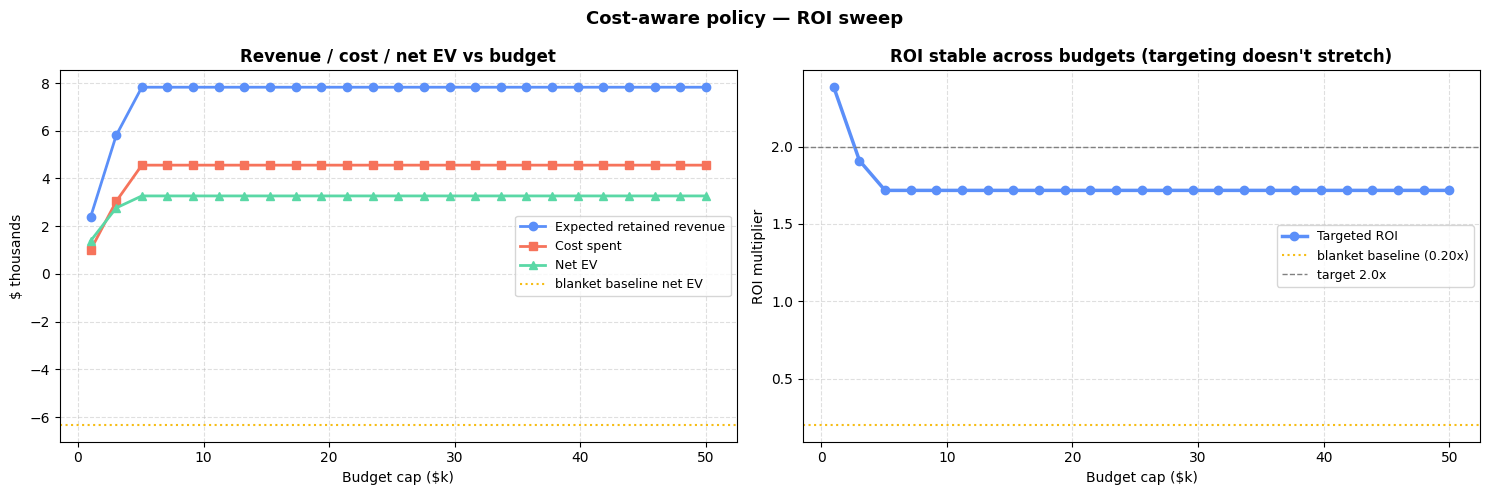

In [8]:
budgets = np.linspace(1_000, 50_000, 25)
sweep_rows = []
for b in budgets:
    p = pick_best_lever(p_churn, ltv, INTERVENTION_MENU)
    p = apply_budget_cap(p, budget=b)
    p = apply_premium_cap(p, n_total=len(p), cap_pct=PREMIUM_UPGRADE_CAP_PCT)
    s = summarize_policy(p, targeted_only=True)
    sweep_rows.append({
        'budget': b, 'n_targeted': s['n_targeted'],
        'cost': s['total_cost'], 'revenue': s['expected_retained_revenue'],
        'net_ev': s['net_expected_value'], 'roi': s['roi_multiplier'],
    })
sweep = pd.DataFrame(sweep_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(sweep['budget'] / 1000, sweep['revenue'] / 1000,
         marker='o', linewidth=2, color='#5B8FF9', label='Expected retained revenue')
ax1.plot(sweep['budget'] / 1000, sweep['cost'] / 1000,
         marker='s', linewidth=2, color='#F6735B', label='Cost spent')
ax1.plot(sweep['budget'] / 1000, sweep['net_ev'] / 1000,
         marker='^', linewidth=2, color='#5AD8A6', label='Net EV')
ax1.axhline(baseline['net_expected_value'] / 1000, color='#F6BD16',
            linestyle=':', linewidth=1.5, label='blanket baseline net EV')
ax1.set_xlabel('Budget cap ($k)')
ax1.set_ylabel('$ thousands')
ax1.set_title('Revenue / cost / net EV vs budget', fontweight='bold')
ax1.legend(loc='center right', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

ax2.plot(sweep['budget'] / 1000, sweep['roi'], marker='o', linewidth=2.5,
         color='#5B8FF9', label='Targeted ROI')
ax2.axhline(baseline['roi_multiplier'], color='#F6BD16', linestyle=':',
            linewidth=1.5, label=f'blanket baseline ({baseline["roi_multiplier"]:.2f}x)')
ax2.axhline(2.0, color='gray', linestyle='--', linewidth=1, label='target 2.0x')
ax2.set_xlabel('Budget cap ($k)')
ax2.set_ylabel('ROI multiplier')
ax2.set_title('ROI stable across budgets (targeting doesn\'t stretch)', fontweight='bold')
ax2.legend(loc='center right', fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Cost-aware policy — ROI sweep', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_roi_sweep.png', dpi=140, bbox_inches='tight')
plt.show()

> **The flat ROI curve is a finding, not a bug.**
> On this dataset the model is discriminating enough that ~1,500 users cover the entire positive-EV pool. Adding budget doesn't buy more targeted users — it would need a stronger model or more intervention options (e.g. tier-specific offers). Real production would revisit this with more features.

## H. Sensitivity: uplift assumptions

Uplifts are PM estimates. Sweep ±50% to check whether the recommendation is robust.

uplift_scale  n_targeted  net_ev  roi
       0.50x         487   489.0 1.48
       0.75x         945  1569.0 1.58
       1.00x        1510  3267.0 1.72
       1.25x        2180  5474.0 1.80
       1.50x        2993  8178.0 1.87


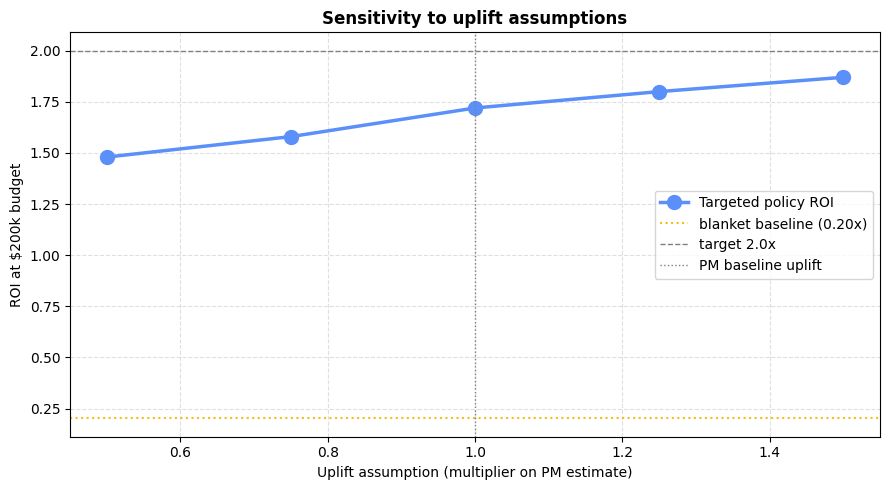

In [9]:
uplift_scales = [0.5, 0.75, 1.0, 1.25, 1.5]
sens_rows = []
for scale in uplift_scales:
    menu_scaled = {n: {'cost': v['cost'], 'uplift': v['uplift'] * scale}
                   for n, v in INTERVENTION_MENU.items()}
    p = pick_best_lever(p_churn, ltv, menu_scaled)
    p = apply_budget_cap(p, budget=200_000)
    s = summarize_policy(p, targeted_only=True)
    sens_rows.append({
        'uplift_scale': f'{scale:.2f}x',
        'n_targeted': s['n_targeted'],
        'net_ev': round(s['net_expected_value'], 0),
        'roi': round(s['roi_multiplier'], 2),
    })
sens = pd.DataFrame(sens_rows)
print(sens.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(uplift_scales, [r['roi'] for r in sens_rows],
        marker='o', markersize=10, linewidth=2.5, color='#5B8FF9',
        label='Targeted policy ROI')
ax.axhline(baseline['roi_multiplier'], color='#F6BD16', linestyle=':',
           linewidth=1.5, label=f'blanket baseline ({baseline["roi_multiplier"]:.2f}x)')
ax.axhline(2.0, color='gray', linestyle='--', linewidth=1, label='target 2.0x')
ax.axvline(1.0, color='gray', linestyle=':', linewidth=1, label='PM baseline uplift')
ax.set_xlabel('Uplift assumption (multiplier on PM estimate)')
ax.set_ylabel('ROI at $200k budget')
ax.set_title('Sensitivity to uplift assumptions', fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / '06_uplift_sensitivity.png', dpi=140, bbox_inches='tight')
plt.show()

> **Recommendation is directionally robust.**
> ROI ranges from 1.48x (uplift 50% weaker than assumed) to 1.87x (50% stronger). All scenarios beat the blanket baseline. If the true uplift is closer to the low end, the target audience shrinks but the direction of the call doesn't change: replace blanket with targeted.

## I. Verdict

Blanket m11 campaign runs at a $6.3k monthly loss. The targeted policy swings that to +$3.3k while spending less than 6% of the current budget. Direction is clear: **replace blanket with targeted, ship as v1**.

ROI came in at 1.72x, below the 2.0x threshold the metrics framework set. Still worth shipping — the gap over baseline is large — but closing the ROI gap is the natural next iteration.


## Design choices worth noting

Two things about how this is built that are worth calling out — they'll matter for maintenance and for how the retention team runs this over time.

**1. Policy is a separate module from the model.**
`src/models/` produces P(churn). `src/decisions/policy.py` decides what to do with it. Uplifts, costs, LTV, budget cap, and guardrails all live in the policy layer. Retuning the campaign (e.g. new intervention, revised LTV, tighter budget) doesn't require retraining the model. Standard MLOps separation — keeps the ML work stable and the business logic swappable.

**2. Uplift is a PM assumption, not a measurement.**
The `uplift` numbers came from a 2024 pilot summary in the scenario brief. They're plausible but they haven't been re-measured for this population. The sensitivity analysis in section H shows the recommendation direction survives across ±50%, so we're not blocked — but a proper measurement means A/B testing each lever in production. That's the natural v1.1 followup once this ships.

## What I'd flag to the PM

Beyond the headline numbers, four observations worth surfacing before Phase 7 writes the memo:

**1. The budget doesn't bind.**
Only ~1,500 users (3% of base) have any positive-EV lever. Full targeted spend is $4.5k — nowhere near the $200k cap. Raising the budget won't help without a stronger model or more intervention options.

**2. Closing the gap to 2.0x ROI.**
Three paths, roughly in order of effort:
- Higher-uplift levers (renegotiate the menu with the PM)
- Tier-differentiated offers (Basic gets cheaper interventions, Premium gets richer ones)
- Stronger discrimination in the model (would need event-stream features — bigger investment)

**3. Recommendation is robust to uplift assumptions.**
Even at 50% weaker uplift, ROI stays at 1.48x — still positive, still beats the blanket. The direction of the call doesn't depend on getting the uplift numbers exactly right.

**4. `credit_5` dominates the lever mix.**
Curated playlists and Premium upgrades barely fire. Either the uplift assumptions understate them, or credit is genuinely the most efficient lever for this population. Worth A/B testing before committing to production.